In [1]:
# ============================================================
# 05_classification_v2.ipynb — Classification, rebuilt cleanly
# Fixes: proper calibration from the start, SHAP-safe base model
#        saved separately, threshold chosen without test leakage
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                       cross_val_predict)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              auc, recall_score, precision_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
os.makedirs('../reports/eda_figures', exist_ok=True)

In [2]:
pipeline = joblib.load('../models/preprocessing_pipeline.joblib')
kmeans_final = joblib.load('../models/kmeans_model.joblib')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Fit pipeline on train only (no leakage), then transform both
pipeline.fit(X_train.drop(columns=['cluster'], errors='ignore'))
X_train_proc = pipeline.transform(X_train.drop(columns=['cluster'], errors='ignore'))
X_test_proc = pipeline.transform(X_test.drop(columns=['cluster'], errors='ignore'))

train_clusters = kmeans_final.predict(X_train_proc)
test_clusters = kmeans_final.predict(X_test_proc)

X_train_final = np.hstack([X_train_proc, train_clusters.reshape(-1, 1)])
X_test_final = np.hstack([X_test_proc, test_clusters.reshape(-1, 1)])

joblib.dump(pipeline, '../models/preprocessing_pipeline.joblib')  # overwrite with train-only fit

print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

X_train_final: (55978, 121)
X_test_final: (13995, 121)
Train positive rate: 0.0897
Test positive rate: 0.0897


In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

params_path = '../reports/best_params.json'

if os.path.exists(params_path):
    with open(params_path) as f:
        best_params = json.load(f)
    print("Reusing existing best_params.json:", best_params)
else:
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 1.5, 2]
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        estimator=XGBClassifier(scale_pos_weight=scale_pos_weight,
                                 eval_metric='logloss', random_state=42, n_jobs=1),
        param_distributions=param_dist, n_iter=20, scoring='roc_auc',
        cv=cv, random_state=42, n_jobs=-1, verbose=2
    )
    search.fit(X_train_final, y_train)
    best_params = search.best_params_
    with open(params_path, 'w') as f:
        json.dump(best_params, f, indent=2)
    print("Best params found:", best_params)
    print("Best CV ROC-AUC:", search.best_score_)

scale_pos_weight: 10.146555157307846
Reusing existing best_params.json: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [4]:
base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    **best_params
)
base_model.fit(X_train_final, y_train)

# Save this RAW model separately — always usable for SHAP, no wrapper
joblib.dump(base_model, '../models/base_xgb_model.joblib')
print("Saved: models/base_xgb_model.joblib  (for SHAP explanations)")

Saved: models/base_xgb_model.joblib  (for SHAP explanations)


In [5]:
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_final, y_train)

probs_test = calibrated_model.predict_proba(X_test_final)[:, 1]

print("Mean predicted probability (test):", probs_test.mean())
print("Actual positive rate (test):", y_test.mean())
print("Min/Max:", probs_test.min(), probs_test.max())
print("ROC-AUC:", roc_auc_score(y_test, probs_test))

Mean predicted probability (test): 0.08923367291350959
Actual positive rate (test): 0.08967488388710254
Min/Max: 0.018607492534301627 0.33911465575598515
ROC-AUC: 0.6497032904488795


In [6]:
# Get out-of-fold calibrated probabilities on TRAIN only, to pick threshold honestly
oof_probs = cross_val_predict(
    CalibratedClassifierCV(XGBClassifier(scale_pos_weight=scale_pos_weight,
                                          eval_metric='logloss', random_state=42,
                                          n_jobs=1, **best_params),
                            method='sigmoid', cv=3),
    X_train_final, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)

target_recall = 0.5
idx = np.argmin(np.abs(recalls - target_recall))
operating_threshold = thresholds[idx]

print(f"Operating threshold (from TRAIN, target recall={target_recall}): {operating_threshold:.4f}")
print(f"OOF Precision: {precisions[idx]:.4f}, OOF Recall: {recalls[idx]:.4f}")

Operating threshold (from TRAIN, target recall=0.5): 0.1023
OOF Precision: 0.1439, OOF Recall: 0.5000


In [7]:
y_pred_test = (probs_test >= operating_threshold).astype(int)

print(classification_report(y_test, y_pred_test))
print("Test Recall:", recall_score(y_test, y_pred_test))
print("Test Precision:", precision_score(y_test, y_pred_test))
print("Test ROC-AUC:", roc_auc_score(y_test, probs_test))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, probs_test)
pr_auc = auc(recall_curve, precision_curve)
print("Test PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     12740
           1       0.15      0.50      0.23      1255

    accuracy                           0.69     13995
   macro avg       0.54      0.61      0.52     13995
weighted avg       0.86      0.69      0.75     13995

Test Recall: 0.503585657370518
Test Precision: 0.14505393619462933
Test ROC-AUC: 0.6497032904488795
Test PR-AUC: 0.18032968200426466


In [8]:
# What do genuinely high-risk patients actually look like?
top_risk_idx = np.argsort(probs_test)[-15:]
print("Top 15 predicted probabilities:", probs_test[top_risk_idx])
print()

X_test_readable = pd.read_csv('../data/processed/X_test.csv')
cols_to_check = ['age_ordinal', 'time_in_hospital', 'num_medications',
                  'number_inpatient', 'number_emergency', 'number_outpatient',
                  'number_diagnoses', 'diag_1_group', 'medical_specialty',
                  'discharge_disposition_id', 'admission_type_id', 'admission_source_id']
cols_to_check = [c for c in cols_to_check if c in X_test_readable.columns]

print(X_test_readable.iloc[top_risk_idx][cols_to_check])

Top 15 predicted probabilities: [0.30352147 0.30752599 0.30756912 0.30906307 0.30911563 0.31004598
 0.31547219 0.31762578 0.31854851 0.31919384 0.32127839 0.3215873
 0.32360816 0.33138004 0.33911466]

       age_ordinal  time_in_hospital  num_medications  number_inpatient  \
1461             6                 2               13                 3   
834              8                 2                7                 0   
1449             6                 6               18                 1   
2663             6                 4               14                 0   
7111             7                 9               17                 0   
295              7                 2                9                 0   
5214             6                 2               20                 1   
4315             6                 6               26                 1   
7680             8                 4               21                 0   
9101             7                 2             

In [9]:
# What actually drives the model's predictions?
importances = base_model.feature_importances_
top_feat_idx = np.argsort(importances)[-15:][::-1]

# Get the actual transformed feature names from the pipeline
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = list(feature_names) + ['cluster']

print("Top 15 most important features:")
for i in top_feat_idx:
    name = feature_names[i] if i < len(feature_names) else f"index_{i}"
    print(f"  {name}: {importances[i]:.4f}")

Top 15 most important features:
  nom__discharge_disposition_id_1: 0.0944
  nom__discharge_disposition_id_22: 0.0362
  num__total_prior_utilization: 0.0293
  nom__diag_1_group_Musculoskeletal: 0.0235
  cluster: 0.0232
  nom__discharge_disposition_id_3: 0.0179
  nom__discharge_disposition_id_5: 0.0164
  num__time_in_hospital: 0.0132
  nom__discharge_disposition_id_23: 0.0131
  nom__discharge_disposition_id_2: 0.0129
  nom__discharge_disposition_id_6: 0.0127
  nom__diag_2_group_Neoplasm: 0.0126
  nom__diabetesMed_Yes: 0.0124
  nom__diag_3_group_Injury: 0.0123
  nom__diag_1_group_Respiratory: 0.0121


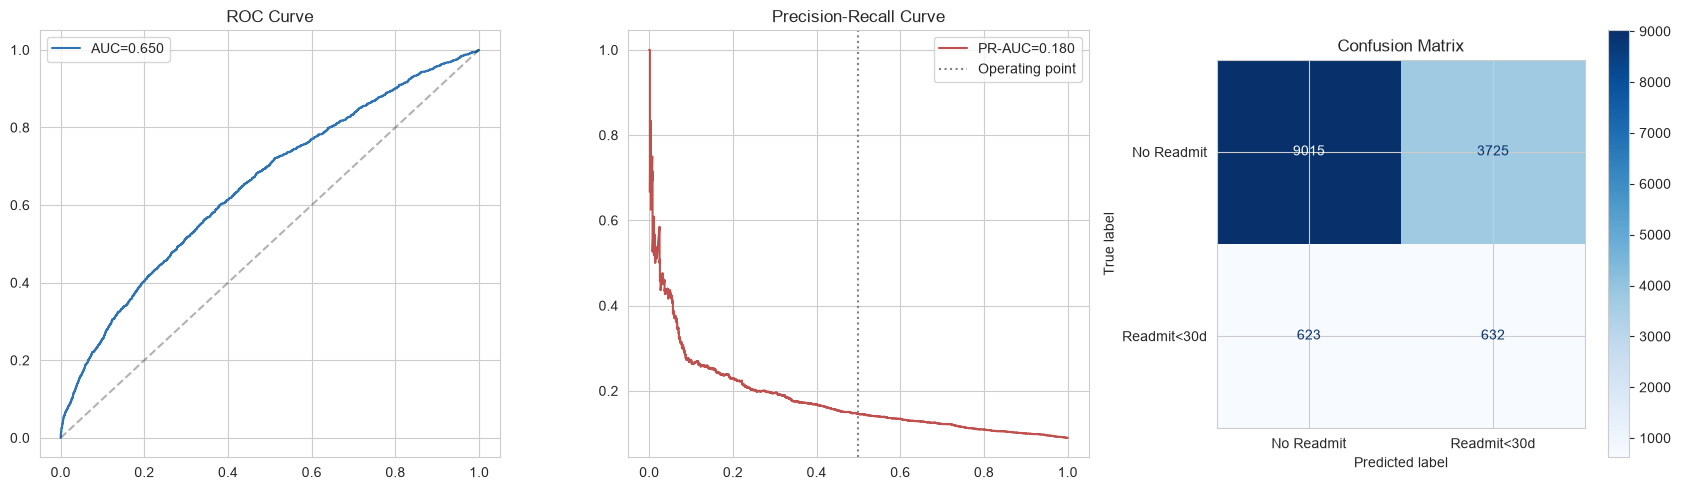

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fpr, tpr, _ = roc_curve(y_test, probs_test)
axes[0].plot(fpr, tpr, color='#2E74B5', label=f'AUC={roc_auc_score(y_test, probs_test):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color='#C0504D', label=f'PR-AUC={pr_auc:.3f}')
axes[1].axvline(recalls[idx], color='gray', linestyle=':', label=f'Operating point')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['No Readmit', 'Readmit<30d']).plot(ax=axes[2], cmap='Blues')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('../reports/eda_figures/model_evaluation_v2.png', dpi=150)
plt.show()

In [11]:
importances = base_model.feature_importances_
top_idx = np.argsort(importances)[-15:][::-1]
print("Top 15 feature importances (by index position):")
for i in top_idx:
    print(f"  index {i}: {importances[i]:.4f}")

Top 15 feature importances (by index position):
  index 24: 0.0944
  index 39: 0.0362
  index 5: 0.0293
  index 68: 0.0235
  index 120: 0.0232
  index 26: 0.0179
  index 28: 0.0164
  index 0: 0.0132
  index 40: 0.0131
  index 25: 0.0129
  index 29: 0.0127
  index 79: 0.0126
  index 103: 0.0124
  index 86: 0.0123
  index 71: 0.0121


In [12]:
joblib.dump(calibrated_model, '../models/classifier.joblib')

config = {
    'operating_threshold': float(operating_threshold),
    'mean_test_probability': float(probs_test.mean()),
    'test_positive_rate': float(y_test.mean()),
    'test_roc_auc': float(roc_auc_score(y_test, probs_test)),
    'test_recall_at_threshold': float(recall_score(y_test, y_pred_test)),
    'test_precision_at_threshold': float(precision_score(y_test, y_pred_test)),
    'risk_tier_low_cutoff': float(np.percentile(probs_test, 50)),
    'risk_tier_high_cutoff': float(np.percentile(probs_test, 85)),
}
with open('../models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
print("  models/classifier.joblib        (calibrated, for predictions)")
print("  models/base_xgb_model.joblib    (raw, for SHAP)")
print("  models/model_config.json        (threshold + tier cutoffs)")
print()
print(json.dumps(config, indent=2))

Saved:
  models/classifier.joblib        (calibrated, for predictions)
  models/base_xgb_model.joblib    (raw, for SHAP)
  models/model_config.json        (threshold + tier cutoffs)

{
  "operating_threshold": 0.10233944787443665,
  "mean_test_probability": 0.08923367291350959,
  "test_positive_rate": 0.08967488388710254,
  "test_roc_auc": 0.6497032904488795,
  "test_recall_at_threshold": 0.503585657370518,
  "test_precision_at_threshold": 0.14505393619462933,
  "risk_tier_low_cutoff": 0.07747777277622825,
  "risk_tier_high_cutoff": 0.13493071366108017
}
